# Down 8 After a Late Touchdown: Go for 2 or Kick?

**DTSC 2301 · Portfolio Project 2 · Micah Shelley**

**Research question.** From 2016–2025, for NFL teams trailing by 8 points at the time of a try with under 10 minutes left in the 4th quarter, does attempting a 2-point conversion produce a higher expected win probability than kicking the PAT, and do observed win rates support the model's prediction?

**How this notebook answers it.**

1. Build a **win-probability (WP) model**: a binary classifier that predicts whether the team with the ball wins the game, given the game state (score, time, timeouts, field position, pregame point spread).
2. Compare a baseline and two models (logistic regression and gradient-boosted trees) on seasons the models never saw.
3. Plug the final model into an expected-value formula for the two choices:
   - `E[WP | kick] = p_PAT · WP(down 7) + (1 − p_PAT) · WP(down 8)`
   - `E[WP | go for 2] = p_2pt · WP(down 6) + (1 − p_2pt) · WP(down 8)`
4. Check those predictions against what actually happened in the 108 real games that fit the situation.

Run the cells top to bottom. The first run downloads about 180 MB of play-by-play data from nflverse into `data/nfl_raw/`.

## 0. Setup

In [1]:
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

RNG = 42
SEASONS = list(range(2016, 2026))
RAW_DIR = "../data/nfl_raw"
FIG_DIR = "../docs/project2"
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# Chart style matched to the portfolio site (palette checked for color-blind separation)
GO2, KICK, NAVY, GRID, MUTED = "#2f5fb3", "#b8862b", "#0a1f44", "#e6e6e6", "#6b6f76"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#9aa0a8", "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlecolor": NAVY,
    "axes.labelcolor": "#333333", "xtick.color": MUTED, "ytick.color": MUTED,
    "legend.frameon": False, "lines.linewidth": 2,
})
def save(fig, name):
    fig.savefig(f"{FIG_DIR}/{name}.png", bbox_inches="tight", facecolor="white")
    plt.show()

## 1. Load the data

**Source:** nflverse play-by-play data (the same data behind the `nflfastR` R package), one file per season. Every row is one play. I keep only the columns needed for this project.

In [2]:
COLS = ["play_id","game_id","season","season_type","week","home_team","away_team","posteam","defteam",
        "qtr","game_seconds_remaining","down","ydstogo","yardline_100","score_differential",
        "posteam_timeouts_remaining","defteam_timeouts_remaining","spread_line",
        "home_score","away_score","result","extra_point_attempt","two_point_attempt",
        "extra_point_result","two_point_conv_result","play_type","desc","vegas_wp","kickoff_attempt"]

def load_season(year):
    path = f"{RAW_DIR}/play_by_play_{year}.csv.gz"
    if not os.path.exists(path):
        url = f"https://github.com/nflverse/nflverse-data/releases/download/pbp/play_by_play_{year}.csv.gz"
        print("downloading", url)
        urllib.request.urlretrieve(url, path)
    return pd.read_csv(path, usecols=COLS, low_memory=False)

pbp = pd.concat([load_season(y) for y in SEASONS], ignore_index=True)
print(f"{len(pbp):,} plays, {pbp.game_id.nunique():,} games, seasons {pbp.season.min()}–{pbp.season.max()}")
pbp.groupby("season").game_id.nunique().rename("games").to_frame().T

484,254 plays, 2,761 games, seasons 2016–2025


season,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
games,267,267,267,267,269,285,284,285,285,285


## 2. Define the target and build the modeling table

- **Unit of analysis:** one play (a game state), seen from the team with the ball (`posteam`).
- **Target:** `win = 1` if the team with the ball won the game, else 0. That makes this a **binary classification** problem.
- Games that ended in a **tie** (10 games) are dropped, since the target is undefined.
- Overtime plays are dropped (the research question is about regulation).
- Try plays (PATs and 2-point attempts) are dropped from the *training* data: they are the decision being studied, not a normal game state.
- Penalty-only rows (`no_play`) and timeout rows are dropped; they repeat the state of a neighboring play and are the only rows with missing timeout counts.

In [3]:
df = pbp.copy()
df["posteam_won"] = np.where(df.posteam == df.home_team, df.result > 0, df.result < 0).astype(int)

ties = df.loc[df.result == 0, "game_id"].nunique()
keep = (
    (df.result != 0)
    & df.posteam.notna()
    & (df.qtr <= 4)
    & df.play_type.isin(["pass","run","punt","field_goal","kickoff","qb_kneel","qb_spike"])
    & (df.two_point_attempt != 1)
)
model_df = df.loc[keep].copy()
print(f"Dropped {ties} tie games. Modeling rows: {len(model_df):,}")
print("Duplicate (game_id, play_id) rows:", model_df.duplicated(["game_id","play_id"]).sum())

Dropped 10 tie games. Modeling rows: 405,821
Duplicate (game_id, play_id) rows: 0


### Feature engineering

Every feature is something known **at the moment of the play**, so nothing leaks from the future.

| Feature | Why it matters |
|---|---|
| `score_differential` | The single biggest driver of who wins |
| `game_seconds_remaining` | A lead matters more as time runs out |
| `diff_time_ratio` | Score differential scaled up as the game goes on (idea borrowed from the nflfastR WP model, Baldwin, 2021) |
| `pos_spread`, `spread_time` | Pregame point spread from the team with the ball's view; its weight fades as the game goes on |
| `posteam_timeouts_remaining`, `defteam_timeouts_remaining` | Timeouts stop the clock late in games |
| `is_home` | Home-field advantage |
| `down`, `ydstogo`, `yardline_100`, `is_kickoff` | Field position and possession situation (kickoffs get down = 0) |

**Deliberately excluded:** `vegas_wp` (nflfastR's own model output), `result`, final scores, and anything else computed after the play. Using those would be data leakage.

In [4]:
def add_features(d):
    d = d.copy()
    d["is_home"] = (d.posteam == d.home_team).astype(int)
    d["pos_spread"] = np.where(d.is_home == 1, d.spread_line, -d.spread_line)   # + = team with ball favored
    d["is_kickoff"] = (d.play_type == "kickoff").astype(int)
    d["down"] = d["down"].fillna(0).astype(int)
    d.loc[d.is_kickoff == 1, "ydstogo"] = 0
    elapsed = (3600 - d.game_seconds_remaining) / 3600
    d["diff_time_ratio"] = d.score_differential / np.exp(-4 * elapsed)
    d["spread_time"] = d.pos_spread * d.game_seconds_remaining / 3600
    return d

FEATURES = ["score_differential","game_seconds_remaining","diff_time_ratio","pos_spread","spread_time",
            "posteam_timeouts_remaining","defteam_timeouts_remaining","is_home",
            "down","ydstogo","yardline_100","is_kickoff"]

model_df = add_features(model_df)
print("Missing values per feature:")
print(model_df[FEATURES + ["posteam_won"]].isna().sum().to_string())
model_df = model_df.dropna(subset=FEATURES)
print(f"\nFinal modeling table: {len(model_df):,} rows × {len(FEATURES)} features")

Missing values per feature:
score_differential            0
game_seconds_remaining        0
diff_time_ratio               0
pos_spread                    0
spread_time                   0
posteam_timeouts_remaining    0
defteam_timeouts_remaining    0
is_home                       0
down                          0
ydstogo                       0
yardline_100                  0
is_kickoff                    0
posteam_won                   0

Final modeling table: 405,821 rows × 12 features


## 3. Explore the data

In [5]:
summary = model_df[FEATURES + ["posteam_won"]].describe().T[["mean","std","min","50%","max"]].round(2)
summary

,mean,std,min,50%,max
score_differential,-1.55,10.50,-56.00,0.00,50.00
game_seconds_remaining,1741.85,1050.29,0.00,1801.00,3600.00
diff_time_ratio,-27.72,275.84,-2640.41,0.00,2631.62
pos_spread,0.04,6.31,-22.00,1.00,22.00
spread_time,0.03,3.58,-22.00,0.01,21.39
posteam_timeouts_remaining,2.59,0.75,0.00,3.00,3.00
defteam_timeouts_remaining,2.60,0.72,0.00,3.00,3.00
is_home,0.50,0.50,0.00,1.00,1.00
down,1.85,1.09,0.00,2.00,4.00
ydstogo,7.95,4.53,0.00,10.00,46.00


In [6]:
print("Target balance (win rate of team with the ball):", round(model_df.posteam_won.mean(), 3))
print("Outlier check: largest score differentials ->", model_df.score_differential.min(), "to", model_df.score_differential.max())

Target balance (win rate of team with the ball): 0.501
Outlier check: largest score differentials -> -56.0 to 50.0


The target is almost perfectly balanced (about 50%). That's expected: every game has one winner and one loser, and both teams have the ball about equally often. So class imbalance is **not** a problem for the WP model. It *is* a problem for the decision data (see below), where only 31 of 108 teams went for 2.

Blowout differentials (±40+) are real values, not errors, so they are kept. Tree models handle them naturally, and the logistic model's `diff_time_ratio` term is bounded by the score.

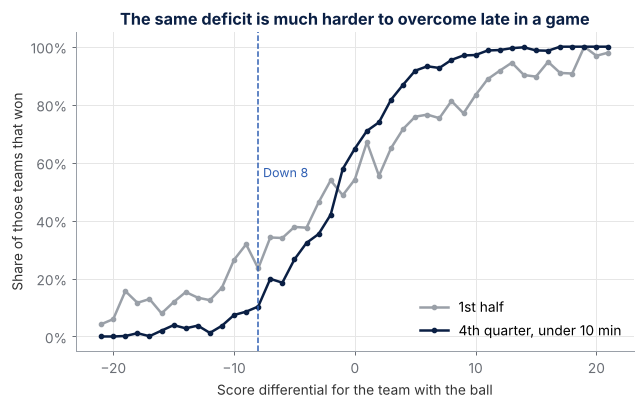

In [7]:
# Figure 1: win rate by score differential, early vs late in the game
fig, ax = plt.subplots(figsize=(8, 4.6))
sub = model_df[model_df.score_differential.between(-21, 21)]
for label, mask, color in [("1st half", sub.game_seconds_remaining > 1800, "#9aa0a8"),
                           ("4th quarter, under 10 min", sub.game_seconds_remaining < 600, NAVY)]:
    g = sub[mask].groupby("score_differential").posteam_won.mean()
    ax.plot(g.index, g.values, color=color, marker="o", markersize=3.5, label=label)
ax.axvline(-8, color=GO2, ls="--", lw=1.2)
ax.text(-7.6, 0.55, "Down 8", color=GO2, fontsize=10)
ax.set(title="The same deficit is much harder to overcome late in a game",
       xlabel="Score differential for the team with the ball", ylabel="Share of those teams that won")
ax.yaxis.set_major_formatter(PercentFormatter(1)); ax.legend(loc="lower right")
save(fig, "fig1_winrate_by_score")

**What this shows:** in the first half, the win-rate curve is gentle: a team down 8 still wins about a third of the time. In the last 10 minutes, the curve becomes a steep S. A team down 8 wins only a small fraction of the time, and every point near zero matters a lot. **Takeaway for modeling:** the effect of the score depends on time remaining, which is why I engineered `diff_time_ratio` and expect a nonlinear model to help.

### The decision situations

In [8]:
tries = df[((df.extra_point_attempt == 1) | (df.two_point_attempt == 1))
           & (df.qtr == 4) & (df.game_seconds_remaining < 600)
           & (df.score_differential == -8) & (df.result != 0)].copy()
# score_differential on a try already includes the touchdown's 6 points (checked by hand on sample rows)
tries["went_for_2"] = (tries.two_point_attempt == 1).astype(int)
tries["converted"] = np.where(tries.went_for_2 == 1, tries.two_point_conv_result == "success",
                              tries.extra_point_result == "good").astype(int)
print(f"{len(tries)} tries: {tries.went_for_2.sum()} went for 2, {(1 - tries.went_for_2).sum()} kicked")
tries.groupby("went_for_2")[["converted","posteam_won"]].agg(["mean","count"]).round(3)

108 tries: 31 went for 2, 77 kicked


converted       posteam_won      
                mean count        mean count
went_for_2                                  
0              0.948    77       0.091    77
1              0.581    31       0.129    31

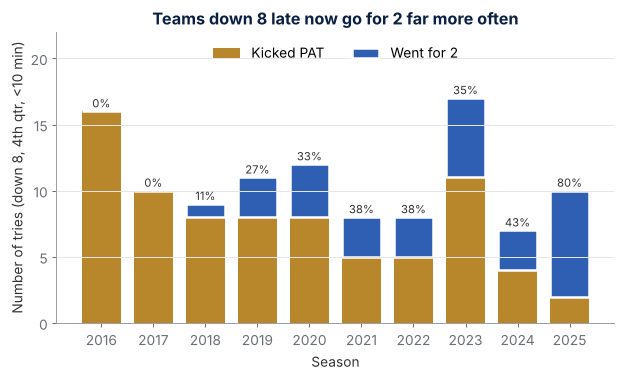

In [9]:
# Figure 2: how often teams went for 2 in this exact spot, by season
by_season = tries.groupby("season").went_for_2.agg(["sum","count"])
by_season["kick"] = by_season["count"] - by_season["sum"]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(by_season.index, by_season["kick"], color=KICK, label="Kicked PAT", width=0.75)
ax.bar(by_season.index, by_season["sum"], bottom=by_season["kick"], color=GO2, label="Went for 2",
       width=0.75, edgecolor="white", linewidth=2)
for s, r in by_season.iterrows():
    ax.text(s, r["count"] + 0.3, f"{r['sum'] / r['count']:.0%}", ha="center", fontsize=9, color="#333")
ax.set(title="Teams down 8 late now go for 2 far more often",
       xlabel="Season", ylabel="Number of tries (down 8, 4th qtr, <10 min)")
ax.set_xticks(by_season.index); ax.grid(axis="x", visible=False)
ax.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.0))
ax.set_ylim(0, by_season["count"].max() + 5); ax.yaxis.get_major_locator().set_params(integer=True)
save(fig, "fig2_attempts_by_season")

**What this shows:** only 108 games fit the exact situation in 10 seasons (110 tries, minus 2 games that ended in ties), and just 31 teams went for 2. The share climbed from 0% in 2016–2017 to 80% in 2025. That small sample is the main reason I train the WP model on *all* plays and only then apply it to this situation. It also means the observed-win-rate check at the end will have wide uncertainty.

In [10]:
# League-wide conversion rates, 2016–2025 (all quarters, all scores): inputs to the decision formula
all_tries = df[(df.extra_point_attempt == 1) | (df.two_point_attempt == 1)]
xp = all_tries[all_tries.extra_point_attempt == 1]
tp = all_tries[all_tries.two_point_attempt == 1]
p_pat = (xp.extra_point_result == "good").mean()
p_2pt = (tp.two_point_conv_result == "success").mean()
print(f"PAT success rate: {p_pat:.3f} (n={len(xp):,})")
print(f"2-pt success rate: {p_2pt:.3f} (n={len(tp):,})")

PAT success rate: 0.944 (n=12,818)
2-pt success rate: 0.476 (n=1,302)


## 4. Train / test split and leakage prevention

- **Split by season, not by random rows.** Train: 2016–2022 · Test: 2023–2025. Plays from the same game share one outcome, so a random row split would put near-copies of a test game in the training data and inflate the scores. A season split keeps whole games together and also tests whether the model holds up in newer seasons, when strategy (like going for 2 more) was changing.
- **Hyperparameter tuning uses only the training seasons**, with `GroupKFold` grouped by `game_id`.
- **Scaling is fit inside a `Pipeline`**, so the test seasons never influence the training means and standard deviations.

In [11]:
train = model_df[model_df.season <= 2022]
test  = model_df[model_df.season >= 2023]
X_tr, y_tr, g_tr = train[FEATURES], train.posteam_won, train.game_id
X_te, y_te = test[FEATURES], test.posteam_won
late_te = (test.qtr == 4) & (test.game_seconds_remaining < 600)   # the region the decision lives in
print(f"Train: {len(train):,} plays ({train.game_id.nunique():,} games) | Test: {len(test):,} plays ({test.game_id.nunique():,} games)")
print(f"Late-game test plays (4th qtr, <10 min): {late_te.sum():,}")

Train: 281,581 plays (1,897 games) | Test: 124,240 plays (854 games)
Late-game test plays (4th qtr, <10 min): 23,837


## 5. Baseline and models

- **Baseline:** predict the training win rate (~50%) for every play. Any useful model must beat this.
- **Model 1: Logistic regression.** Simple and interpretable. Numbers are standardized; `down` is one-hot encoded because downs aren't evenly spaced in meaning.
- **Model 2: Histogram gradient-boosted trees.** Captures nonlinear interactions (score × time × timeouts) without me hand-writing them. I add **monotonic constraints**: win probability can only go *up* as your lead grows or as your pregame spread improves. This keeps the model's logic sensible in rare game states where data is thin.

In [12]:
base_rate = y_tr.mean()

num_cols = [c for c in FEATURES if c != "down"]
def make_logit():
    return Pipeline([
        ("prep", ColumnTransformer([("num", StandardScaler(), num_cols),
                                    ("down", OneHotEncoder(handle_unknown="ignore"), ["down"])])),
        ("clf", LogisticRegression(max_iter=2000, C=1.0)),
    ])
logit = make_logit().fit(X_tr, y_tr)

mono = [1 if f in ("score_differential","diff_time_ratio","pos_spread","spread_time") else 0 for f in FEATURES]
def make_gbm(**kw):
    return HistGradientBoostingClassifier(monotonic_cst=mono, max_iter=400, early_stopping=False,
                                          random_state=RNG, **kw)

In [13]:
# Hyperparameter tuning: 3-fold GroupKFold (grouped by game) on the TRAINING seasons only
grid = [dict(learning_rate=lr, max_leaf_nodes=leaves, l2_regularization=l2)
        for lr in (0.05, 0.1) for leaves in (15, 31, 63) for l2 in (0.0, 1.0)]
gkf = GroupKFold(n_splits=3)
results = []
for params in grid:
    losses = []
    for tr_idx, va_idx in gkf.split(X_tr, y_tr, g_tr):
        m = make_gbm(**params).fit(X_tr.iloc[tr_idx], y_tr.iloc[tr_idx])
        losses.append(log_loss(y_tr.iloc[va_idx], m.predict_proba(X_tr.iloc[va_idx])[:, 1]))
    results.append({**params, "cv_log_loss": np.mean(losses)})
tuning = pd.DataFrame(results).sort_values("cv_log_loss")
best = tuning.iloc[0][["learning_rate","max_leaf_nodes","l2_regularization"]].to_dict()
best["max_leaf_nodes"] = int(best["max_leaf_nodes"])
print("Best settings:", best)
tuning.head(6).round(5)

Best settings: {'learning_rate': 0.05, 'max_leaf_nodes': 15, 'l2_regularization': 1.0}


,learning_rate,max_leaf_nodes,l2_regularization,cv_log_loss
1,0.05,15,1.0,0.44622
0,0.05,15,0.0,0.44689
3,0.05,31,1.0,0.44722
2,0.05,31,0.0,0.44835
7,0.10,15,1.0,0.44913
5,0.05,63,1.0,0.44937


In [14]:
gbm = make_gbm(**best).fit(X_tr, y_tr)

## 6. Evaluate on the held-out seasons (2023–2025)

Because the final step plugs **probabilities** into an expected-value formula, probability accuracy matters more than simply picking the right winner.

- **Log loss:** penalizes confident wrong probabilities heavily. Lower is better.
- **Brier score:** mean squared error of the probability. Lower is better; 0.25 = coin flip.
- **ROC AUC:** how well the model ranks winners above losers (0.5 = random, 1 = perfect). Note it ignores calibration.
- Everything is also reported on the **late-game subset** (4th quarter, under 10 minutes), the region where the 2-point decision happens.

For context only, I also score nflfastR's published `vegas_wp` column. It is **not** used as a feature; it's a benchmark from a professionally built model.

In [15]:
def scores(y, p):
    return {"log_loss": log_loss(y, p), "brier": brier_score_loss(y, p), "roc_auc": roc_auc_score(y, p)}

preds = {
    "Baseline (always ~50%)": np.full(len(y_te), base_rate),
    "Logistic regression": logit.predict_proba(X_te)[:, 1],
    "Gradient boosting (tuned)": gbm.predict_proba(X_te)[:, 1],
}
rows = []
for name, p in preds.items():
    rows.append({"model": name, **{f"all_{k}": v for k, v in scores(y_te, p).items()},
                 **{f"late_{k}": v for k, v in scores(y_te[late_te], p[late_te.values]).items()}})
nfl_wp = test.vegas_wp.clip(1e-4, 1 - 1e-4)
ok = nfl_wp.notna()
rows.append({"model": "Reference: nflfastR vegas_wp",
             **{f"all_{k}": v for k, v in scores(y_te[ok], nfl_wp[ok]).items()},
             **{f"late_{k}": v for k, v in scores(y_te[ok & late_te], nfl_wp[ok & late_te]).items()}})
eval_table = pd.DataFrame(rows).set_index("model").round(4)
eval_table.loc["Baseline (always ~50%)", ["all_roc_auc", "late_roc_auc"]] = 0.5
eval_table

,all_log_loss,all_brier,all_roc_auc,late_log_loss,late_brier,late_roc_auc
model,,,,,,
Baseline (always ~50%),0.6931,0.2500,0.5000,0.6932,0.2500,0.5000
Logistic regression,0.4498,0.1490,0.8667,0.2833,0.0903,0.9500
Gradient boosting (tuned),0.4541,0.1507,0.8639,0.2831,0.0904,0.9503
Reference: nflfastR vegas_wp,0.4476,0.1482,0.8683,0.2719,0.0869,0.9538


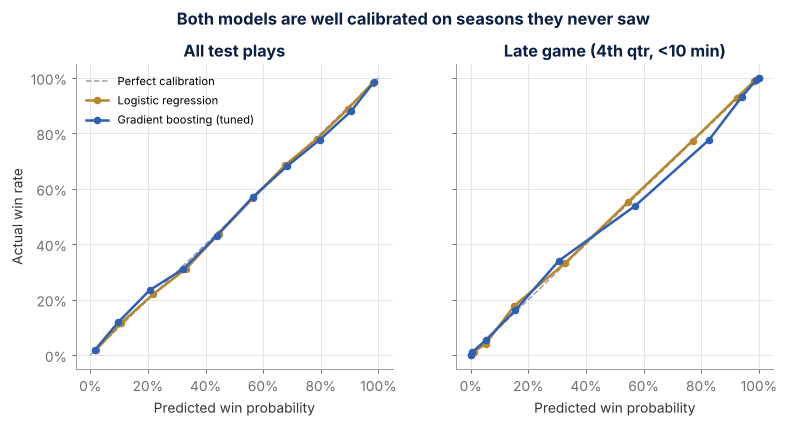

In [16]:
# Figure 3: calibration on the held-out seasons
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4), sharey=True)
for ax, (title, mask) in zip(axes, [("All test plays", np.ones(len(y_te), bool)),
                                    ("Late game (4th qtr, <10 min)", late_te.values)]):
    ax.plot([0, 1], [0, 1], color="#9aa0a8", ls="--", lw=1.2, label="Perfect calibration")
    for name, color in [("Logistic regression", KICK), ("Gradient boosting (tuned)", GO2)]:
        frac, mean_p = calibration_curve(y_te[mask], preds[name][mask], n_bins=10, strategy="quantile")
        ax.plot(mean_p, frac, marker="o", markersize=5, color=color, label=name)
    ax.set(title=title, xlabel="Predicted win probability")
    ax.xaxis.set_major_formatter(PercentFormatter(1)); ax.yaxis.set_major_formatter(PercentFormatter(1))
axes[0].set_ylabel("Actual win rate"); axes[0].legend(loc="upper left", fontsize=9)
fig.suptitle("Both models are well calibrated on seasons they never saw", color=NAVY, fontweight="bold", y=1.02)
save(fig, "fig3_calibration")

## 7. Stress test: do the models give a *stable* answer to the decision?

The aggregate scores above are close. But the decision doesn't depend on overall accuracy; it depends on **tiny differences** between the win probability of a team down 6, down 7, and down 8. A model can be well calibrated overall and still get those differences wrong.

**Test:** resample whole games with replacement (a bootstrap, 25 times), refit each model, and recompute the expected-WP gain from going for 2 in a typical situation (3 timeouts each, evenly matched teams). A trustworthy model should give a similar answer every time.

In [17]:
def kickoff_state(lead, secs, lead_to, trail_to, lead_home, lead_spread):
    # Game state on the kickoff right after the try, from the LEADING (receiving) team's view
    secs = np.asarray(secs, float)
    d = pd.DataFrame({"score_differential": float(lead), "game_seconds_remaining": secs,
                      "posteam_timeouts_remaining": lead_to, "defteam_timeouts_remaining": trail_to,
                      "spread_line": 0.0, "down": 0, "ydstogo": 0, "yardline_100": 35.0,
                      "play_type": "kickoff", "posteam": "A", "home_team": "A"})
    d = add_features(d)
    d["is_home"] = lead_home
    d["pos_spread"] = lead_spread
    d["spread_time"] = d.pos_spread * d.game_seconds_remaining / 3600
    return d[FEATURES]

def trailing_wp(model, lead, **state):
    return 1 - model.predict_proba(kickoff_state(lead, **state))[:, 1]

def expected_wp(model, state, p2=p_2pt, pk=p_pat):
    wp6, wp7, wp8 = (trailing_wp(model, lead, **state) for lead in (6, 7, 8))
    go2 = p2 * wp6 + (1 - p2) * wp8
    kick = pk * wp7 + (1 - pk) * wp8
    breakeven = pk * (wp7 - wp8) / (wp6 - wp8)
    return go2, kick, breakeven, wp6, wp7, wp8

mins = np.arange(1, 10.01, 0.5)
def typical_curve(model):
    # neutral game: 3 timeouts each, pick'em spread, averaged over the leader being home/away
    res = [expected_wp(model, dict(secs=mins * 60, lead_to=3, trail_to=3, lead_home=h, lead_spread=0.0)) for h in (0, 1)]
    return [(a + b) / 2 for a, b in zip(*res)]

def wilson(k, n, z=1.96):
    p = k / n; den = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / den; h = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    return c - h, c + h

In [18]:
B = 25
rng = np.random.default_rng(RNG)
games = model_df.game_id.unique()
rows_by_game = model_df.groupby("game_id").indices
boot = {"Logistic regression": [], "Gradient boosting (tuned)": []}
for b in range(B):
    pick = rng.choice(games, size=len(games), replace=True)
    idx = np.concatenate([rows_by_game[g] for g in pick])
    Xb, yb = model_df[FEATURES].iloc[idx], model_df.posteam_won.iloc[idx]
    for name, maker in [("Logistic regression", make_logit), ("Gradient boosting (tuned)", lambda: make_gbm(**best))]:
        go2, kick, *_ = typical_curve(maker().fit(Xb, yb))
        boot[name].append((go2 - kick) * 100)
stab = {name: np.array(v) for name, v in boot.items()}
for name, arr in stab.items():
    flips = np.mean([(r > 0).any() and (r < 0).any() for r in arr])
    print(f"{name:28s} median gain {np.median(arr):+.2f} pts | share of (fit, minute) pairs favoring go-for-2: "
          f"{(arr > 0).mean():.0%} | fits whose answer flips by minute: {flips:.0%}")

Logistic regression          median gain +0.29 pts | share of (fit, minute) pairs favoring go-for-2: 100% | fits whose answer flips by minute: 0%
Gradient boosting (tuned)    median gain -0.52 pts | share of (fit, minute) pairs favoring go-for-2: 28% | fits whose answer flips by minute: 92%


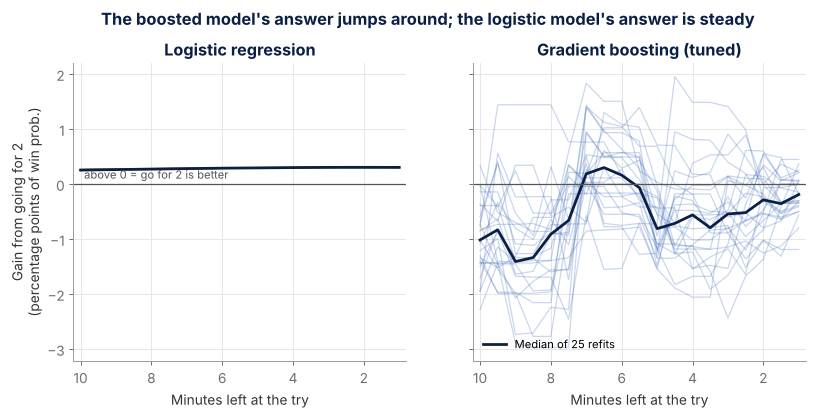

In [19]:
# Figure 4: decision stability across bootstrap refits
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3), sharey=True)
for ax, (name, color) in zip(axes, [("Logistic regression", KICK), ("Gradient boosting (tuned)", GO2)]):
    arr = stab[name]
    for r in arr:
        ax.plot(mins, r, color=color, alpha=0.25, lw=1)
    ax.plot(mins, np.median(arr, axis=0), color=NAVY, lw=2.2, label="Median of 25 refits")
    ax.axhline(0, color="#555", lw=1)
    ax.set(title=name, xlabel="Minutes left at the try")
    ax.set_xlim(10.2, 0.8)
axes[0].set_ylabel("Gain from going for 2\n(percentage points of win prob.)")
axes[0].text(9.9, 0.05, "above 0 = go for 2 is better", fontsize=9, color="#555", va="bottom")
axes[1].legend(loc="lower left", fontsize=9)
fig.suptitle("The boosted model's answer jumps around; the logistic model's answer is steady",
             color=NAVY, fontweight="bold", y=1.02)
save(fig, "fig4_decision_stability")

**What this shows and why the models differ.** Gradient boosting splits `score_differential` into bins chosen wherever they help the *overall* fit. Kickoffs with a 6-, 7-, or 8-point lead late in a game are a tiny slice of the data, so the exact cut points around those margins move with every resample, and the go-for-2 answer flips from minute to minute and from refit to refit. That is **variance**, not football knowledge. Logistic regression assumes win probability changes smoothly with the score, so it reaches the same answer every time.

**Final model: logistic regression.** It matched or beat gradient boosting on held-out log loss and Brier score, it is well calibrated in the late-game region, and it is the only model whose answer to the research question is stable. The trade-off: a smooth model cannot represent football's "key numbers" (a 7-point deficit is a different situation from 8 because of the 2-point try). Section 9 checks how much that matters.

## 8. Interpret the final model

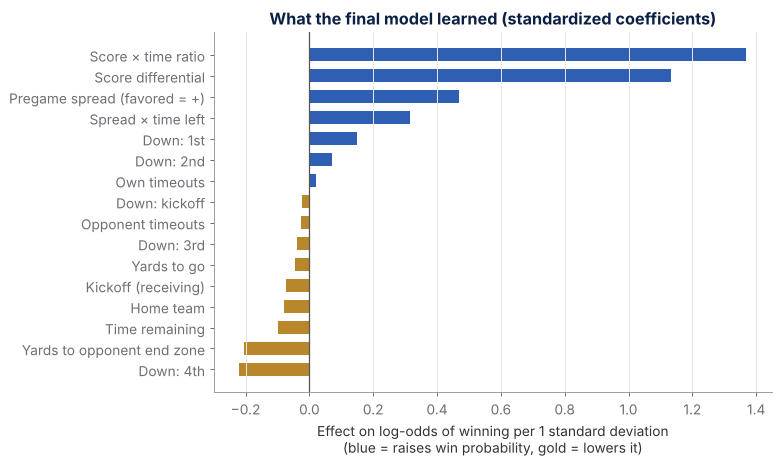

Score × time ratio              1.370
Score differential              1.133
Pregame spread (favored = +)    0.469
Spread × time left              0.315
Down: 4th                      -0.220
Yards to opponent end zone     -0.205
Down: 1st                       0.150
Time remaining                 -0.099
Home team                      -0.078
Kickoff (receiving)            -0.075
Down: 2nd                       0.072
Yards to go                    -0.044
Down: 3rd                      -0.038
Opponent timeouts              -0.026
Down: kickoff                  -0.023
Own timeouts                    0.020
dtype: float64

In [20]:
final = make_logit().fit(model_df[FEATURES], model_df.posteam_won)   # refit on all seasons for interpretation and charts
names = final.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(final.named_steps["clf"].coef_[0], index=names)
nice = {"num__score_differential":"Score differential","num__diff_time_ratio":"Score × time ratio",
        "num__pos_spread":"Pregame spread (favored = +)","num__spread_time":"Spread × time left",
        "num__game_seconds_remaining":"Time remaining","num__yardline_100":"Yards to opponent end zone",
        "num__posteam_timeouts_remaining":"Own timeouts","num__defteam_timeouts_remaining":"Opponent timeouts",
        "num__ydstogo":"Yards to go","num__is_home":"Home team","num__is_kickoff":"Kickoff (receiving)",
        "down__down_0":"Down: kickoff","down__down_1":"Down: 1st","down__down_2":"Down: 2nd",
        "down__down_3":"Down: 3rd","down__down_4":"Down: 4th"}
c = coefs.rename(nice).sort_values()
fig, ax = plt.subplots(figsize=(8, 5.2))
ax.barh(c.index, c.values, color=[GO2 if v > 0 else KICK for v in c.values], height=0.62)
ax.axvline(0, color="#555", lw=1)
ax.set(title="What the final model learned (standardized coefficients)",
       xlabel="Effect on log-odds of winning per 1 standard deviation\n(blue = raises win probability, gold = lowers it)")
ax.grid(axis="y", visible=False)
save(fig, "fig5_coefficients")
coefs.rename(nice).sort_values(key=abs, ascending=False).round(3)

**Reading the coefficients:** the biggest effects are score and the score-by-time ratio: a lead is worth far more late in the game. The pregame spread matters, but its weight fades as the game goes on (the spread × time term). Field position (yards to the end zone) and timeouts matter less on average across all plays, though they can matter a lot in specific late-game moments.

In [21]:
# Error analysis: where is the final model least accurate? (held-out seasons, model trained on 2016–2022)
p_log = preds["Logistic regression"]
phase = pd.cut(test.game_seconds_remaining, [0, 120, 600, 1800, 3600],
               labels=["Last 2 min", "2–10 min left", "2nd half, >10 min", "1st half"], include_lowest=True)
close = np.where(test.score_differential.abs() <= 8, "one-score game", "two+ scores")
err = pd.DataFrame({"phase": phase.values, "margin": close, "sq_err": (p_log - y_te.values) ** 2})
err.groupby(["phase", "margin"], observed=True).sq_err.agg(["mean","count"]).round(3).rename(columns={"mean":"brier"}).unstack()

brier                      count            
margin            one-score game two+ scores one-score game two+ scores
phase                                                                  
Last 2 min                 0.141       0.000           4132        2438
2–10 min left              0.172       0.021           8031        9263
2nd half, >10 min          0.193       0.063          20049       18299
1st half                   0.200       0.105          50696       11332

## 9. The decision: go for 2 or kick?

After the try, the leading team receives a kickoff. So for each option I ask the model for the **leading team's** WP on that kickoff when it leads by 6, 7, or 8, and convert it to the trailing team's WP (1 − p).

**Avoiding leakage in the decision step:** for each real try, I use a model trained on **every season except that one** (leave-one-season-out). So no game's own outcome ever informs its own prediction.

In [22]:
tries = add_features(tries)
state_cols = dict(secs=tries.game_seconds_remaining.values,
                  lead_to=tries.defteam_timeouts_remaining.values,
                  trail_to=tries.posteam_timeouts_remaining.values,
                  lead_home=1 - tries.is_home.values,
                  lead_spread=-tries.pos_spread.values)
out = {k: np.zeros(len(tries)) for k in ["go2","kick","breakeven","wp6","wp7","wp8"]}
for s in SEASONS:
    idx = np.where(tries.season.values == s)[0]
    if len(idx) == 0: continue
    m = make_logit().fit(model_df.loc[model_df.season != s, FEATURES], model_df.loc[model_df.season != s, "posteam_won"])
    st = {k: v[idx] for k, v in state_cols.items()}
    for k, v in zip(out, expected_wp(m, st)):
        out[k][idx] = v
for k, v in out.items():
    tries[f"pred_{k}"] = v
tries["gain_go2"] = tries.pred_go2 - tries.pred_kick
print(f"Situations: {len(tries)}")
print(f"Average expected WP if going for 2: {tries.pred_go2.mean():.3f}")
print(f"Average expected WP if kicking:     {tries.pred_kick.mean():.3f}")
print(f"Model favors going for 2 in {(tries.gain_go2 > 0).mean():.0%} of situations; "
      f"mean gain = {tries.gain_go2.mean() * 100:+.2f} percentage points "
      f"(relative gain {tries.gain_go2.mean() / tries.pred_kick.mean():+.0%})")
print(f"Break-even 2-pt success rate: median {tries.pred_breakeven.median():.3f} "
      f"(range {tries.pred_breakeven.min():.3f}–{tries.pred_breakeven.max():.3f}) vs league rate {p_2pt:.3f}")

Situations: 108
Average expected WP if going for 2: 0.072
Average expected WP if kicking:     0.069
Model favors going for 2 in 100% of situations; mean gain = +0.25 percentage points (relative gain +4%)
Break-even 2-pt success rate: median 0.408 (range 0.387–0.438) vs league rate 0.476


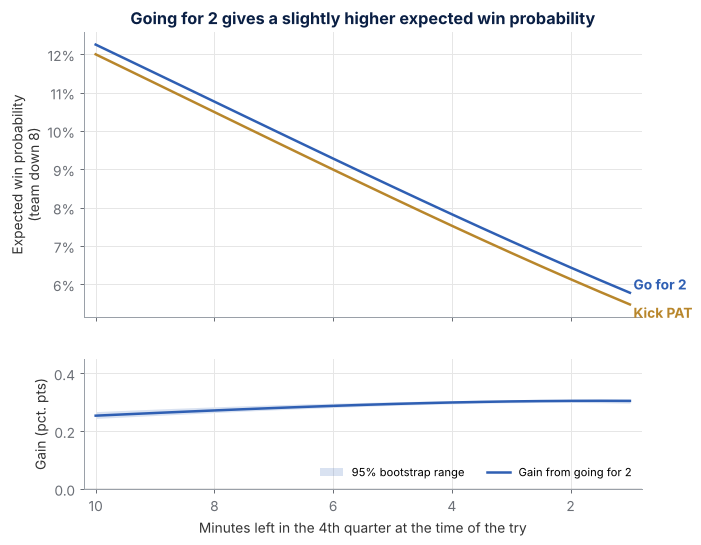

,minutes_left,go_for_2,kick,gain_pts,breakeven_2pt_rate
0,1.0,0.058,0.055,0.305,0.397
3,2.5,0.068,0.065,0.304,0.404
6,4.0,0.078,0.075,0.300,0.409
9,5.5,0.089,0.086,0.291,0.415
12,7.0,0.100,0.097,0.280,0.420
15,8.5,0.111,0.109,0.268,0.424
18,10.0,0.123,0.120,0.254,0.428


In [23]:
# Figure 6: expected WP of each choice by minutes left (typical game), with bootstrap band on the gain
go2_c, kick_c, be_c, *_ = typical_curve(final)
lo_g, hi_g = np.percentile(stab["Logistic regression"], [2.5, 97.5], axis=0)

fig, axes = plt.subplots(2, 1, figsize=(8, 6.6), sharex=True, gridspec_kw={"height_ratios": [2.2, 1]})
ax = axes[0]
ax.plot(mins, go2_c, color=GO2); ax.plot(mins, kick_c, color=KICK)
ax.text(1.05, go2_c[0], "  Go for 2", color=GO2, va="bottom", fontweight="bold")
ax.text(1.05, kick_c[0], "  Kick PAT", color=KICK, va="top", fontweight="bold")
ax.set(title="Going for 2 gives a slightly higher expected win probability",
       ylabel="Expected win probability\n(team down 8)")
ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax2 = axes[1]
ax2.fill_between(mins, lo_g, hi_g, color=GO2, alpha=0.18, linewidth=0, label="95% bootstrap range")
ax2.plot(mins, (go2_c - kick_c) * 100, color=GO2, label="Gain from going for 2")
ax2.axhline(0, color="#555", lw=1)
ax2.set(xlabel="Minutes left in the 4th quarter at the time of the try", ylabel="Gain (pct. pts)")
ax2.legend(loc="lower right", fontsize=9, ncol=2); ax2.set_ylim(0, 0.45)
ax2.set_xlim(10.2, 0.8)
save(fig, "fig6_decision_curve")
pd.DataFrame({"minutes_left": mins, "go_for_2": go2_c, "kick": kick_c, "gain_pts": (go2_c - kick_c) * 100,
              "breakeven_2pt_rate": be_c}).iloc[::3].round(3)

League 2-pt rate 0.476, 95% CI 0.449–0.503


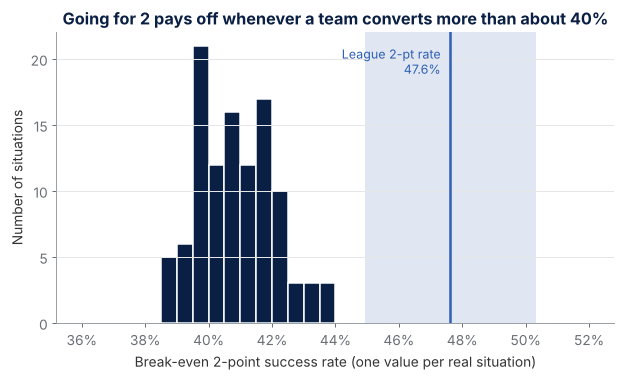

In [24]:
# Figure 7: break-even 2-pt rate per real situation vs the league's actual rate (with 95% Wilson interval)
n2 = len(tp); k2 = int((tp.two_point_conv_result == "success").sum())
lo2, hi2 = wilson(k2, n2)
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(tries.pred_breakeven, bins=np.arange(0.36, 0.52, 0.005), color=NAVY, edgecolor="white", linewidth=1.2)
ax.set_xticks(np.arange(0.36, 0.521, 0.02)); ax.yaxis.get_major_locator().set_params(integer=True)
ax.axvspan(lo2, hi2, color=GO2, alpha=0.15, linewidth=0)
ax.axvline(p_2pt, color=GO2, lw=2)
ax.text(p_2pt - 0.003, ax.get_ylim()[1] * 0.95, f"League 2-pt rate\n{p_2pt:.1%}", color=GO2, fontsize=10, va="top", ha="right")
ax.set(title="Going for 2 pays off whenever a team converts more than about 40%",
       xlabel="Break-even 2-point success rate (one value per real situation)", ylabel="Number of situations")
ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=0)); ax.grid(axis="x", visible=False)
save(fig, "fig7_breakeven")
print(f"League 2-pt rate {p_2pt:.3f}, 95% CI {lo2:.3f}–{hi2:.3f}")

### Cross-check: what does the raw data say about down 6 vs 7 vs 8?

The smooth model can't see key numbers, so here is a model-free check: among real 4th-quarter kickoffs with under 10 minutes left, how often did the kicking team come back to win when it trailed by exactly 6, 7, or 8?

In [25]:
ko = model_df[(model_df.is_kickoff == 1) & (model_df.qtr == 4) & (model_df.game_seconds_remaining < 600)]
emp = []
for lead in (6, 7, 8):
    g = ko[ko.score_differential == lead]
    k, n = int((1 - g.posteam_won).sum()), len(g)
    lo, hi = wilson(k, n)
    emp.append({"trailing_by": lead, "kickoffs": n, "comebacks": k, "comeback_rate": k / n, "ci_low": lo, "ci_high": hi,
                "model_avg_wp": trailing_wp(final, lead, secs=g.game_seconds_remaining.values,
                                            lead_to=g.posteam_timeouts_remaining.values,
                                            trail_to=g.defteam_timeouts_remaining.values,
                                            lead_home=g.is_home.values, lead_spread=g.pos_spread.values).mean()})
emp = pd.DataFrame(emp).set_index("trailing_by")
w6, w7, w8 = emp.comeback_rate
print(f"Raw-data version of the formula: go for 2 = {p_2pt*w6 + (1-p_2pt)*w8:.3f}, kick = {p_pat*w7 + (1-p_pat)*w8:.3f}")
emp.round(3)

Raw-data version of the formula: go for 2 = 0.090, kick = 0.071


,kickoffs,comebacks,comeback_rate,ci_low,ci_high,model_avg_wp
trailing_by,,,,,,
6,99,11,0.111,0.063,0.188,0.094
7,198,14,0.071,0.043,0.115,0.071
8,127,9,0.071,0.038,0.129,0.054


**Takeaway:** in the raw data, being down 7 was no better than being down 8, while being down 6 was clearly better. That gap is the "key number" effect that the smooth model averages away. If those raw rates are anywhere near right, the true advantage of going for 2 is **larger** than my model estimates, so the model's recommendation is conservative. The intervals are wide, though, and teams don't land in these spots at random, so this is a sanity check, not proof.

## 10. Do observed win rates support the model?

Compare the model's average predicted win probability for the option each team actually chose against how often those teams actually won.

In [26]:
tries["pred_chosen"] = np.where(tries.went_for_2 == 1, tries.pred_go2, tries.pred_kick)
obs = []
for choice, g in tries.groupby("went_for_2"):
    k, n = int(g.posteam_won.sum()), len(g)
    lo, hi = wilson(k, n)
    obs.append({"choice": "Went for 2" if choice else "Kicked PAT", "n": n, "wins": k,
                "observed_win_rate": k / n, "ci_low": lo, "ci_high": hi,
                "model_predicted": g.pred_chosen.mean(),
                "model_if_other_choice": (g.pred_kick if choice else g.pred_go2).mean()})
obs = pd.DataFrame(obs).set_index("choice")
obs.round(3)

,n,wins,observed_win_rate,ci_low,ci_high,model_predicted,model_if_other_choice
choice,,,,,,,
Kicked PAT,77,7,0.091,0.045,0.176,0.073,0.075
Went for 2,31,4,0.129,0.051,0.289,0.063,0.061


In [27]:
from scipy.stats import fisher_exact
ct = pd.crosstab(tries.went_for_2, tries.posteam_won)
odds, p_fisher = fisher_exact(ct.values)
print(ct); print(f"Fisher's exact test p-value: {p_fisher:.3f}")
print(f"Overall: predicted {tries.pred_chosen.mean():.3f} vs observed {tries.posteam_won.mean():.3f}")
conv = tries[tries.went_for_2 == 1]
print(f"2-pt tries in this situation converted: {conv.converted.sum()} of {len(conv)}; "
      f"win rate when converted {conv[conv.converted == 1].posteam_won.mean():.2f}, when failed {conv[conv.converted == 0].posteam_won.mean():.2f}")

posteam_won   0  1
went_for_2        
0            70  7
1            27  4
Fisher's exact test p-value: 0.726
Overall: predicted 0.070 vs observed 0.102
2-pt tries in this situation converted: 18 of 31; win rate when converted 0.17, when failed 0.08


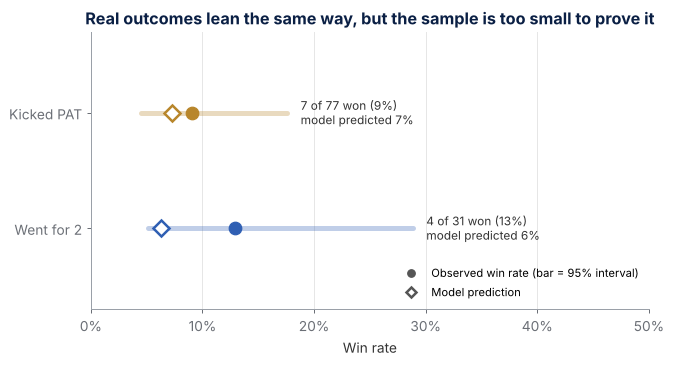

In [28]:
# Figure 8: predicted vs observed, with 95% intervals
fig, ax = plt.subplots(figsize=(8, 4.0))
y = np.arange(len(obs))[::-1]
for yi, (name, r) in zip(y, obs.iterrows()):
    color = GO2 if name == "Went for 2" else KICK
    ax.plot([r.ci_low, r.ci_high], [yi, yi], color=color, lw=4, alpha=0.3, solid_capstyle="round")
    ax.plot(r.observed_win_rate, yi, "o", color=color, markersize=10)
    ax.plot(r.model_predicted, yi, "D", markersize=9, markerfacecolor="white", markeredgecolor=color, markeredgewidth=2)
    ax.text(r.ci_high + 0.012, yi, f"{int(r.wins)} of {int(r.n)} won ({r.observed_win_rate:.0%})\nmodel predicted {r.model_predicted:.0%}",
            va="center", fontsize=9.5, color="#333")
ax.set_yticks(y, obs.index); ax.set_xlim(0, 0.5); ax.set_ylim(-0.7, len(obs) - 0.3)
ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax.plot([], [], "o", color="#555", label="Observed win rate (bar = 95% interval)")
ax.plot([], [], "D", markerfacecolor="white", markeredgecolor="#555", markeredgewidth=2, label="Model prediction")
ax.legend(loc="lower right", fontsize=9)
ax.set(title="Real outcomes lean the same way, but the sample is too small to prove it", xlabel="Win rate")
ax.grid(axis="y", visible=False)
save(fig, "fig8_observed_vs_predicted")

In [29]:
# Save the decision situations (small file) for transparency
keep_cols = ["season","week","game_id","posteam","defteam","game_seconds_remaining","posteam_timeouts_remaining",
             "defteam_timeouts_remaining","pos_spread","went_for_2","converted","posteam_won",
             "pred_go2","pred_kick","gain_go2","pred_breakeven","desc"]
tries[keep_cols].sort_values(["season","week"]).to_csv("../data/nfl_down8_tries_2016_2025.csv", index=False)
print("saved", len(tries), "rows")

saved 108 rows


## 11. Conclusions

- **Model selection:** logistic regression and tuned gradient boosting were nearly tied on held-out seasons (log loss 0.450 vs 0.454; late-game Brier 0.090 for both), and both crushed the baseline (0.693). Logistic regression was chosen because its answer to the decision question was stable across 25 bootstrap refits, while the boosted model favored going for 2 in only 28% of its estimates and switched answers from minute to minute in 92% of refits.
- **The decision:** in all 108 real situations, the final model gives going for 2 a higher expected win probability than kicking, by about +0.25 percentage points on average (about a 4% relative improvement on a ~7% win chance).
- **Break-even:** going for 2 pays off whenever a team converts more than about 39–44% of the time. The league converted 47.6% from 2016–2025.
- **Conservative estimate:** the raw data shows being down 7 was no better than being down 8, a key-number effect the smooth model can't capture. If that's real, going for 2 is worth even more than the model says.
- **Observed outcomes:** teams that went for 2 won 13% of the time (4 of 31) vs. 9% for kickers (7 of 77), even though the model rated the go-for-2 teams' situations as slightly *worse*. That points the same way as the model, but the sample is far too small to be significant (Fisher's exact p = 0.73).

See the published write-up for limitations and ethics.